In [28]:
import pennylane as qml

#BASIS ENCODING
dev = qml.device("default.qubit", range(3))
@qml.qnode(dev)
def circuit(x):
    qml.BasisEmbedding(x, range(3))
    return qml.state()

circuit(6)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j])

In [29]:
import pennylane as qml
import numpy as np

#AMPLITUDE ENCODING
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    qml.AmplitudeEmbedding(features=x, wires=range(n_qubits), normalize=True, pad_with=0.)
    return(qml.state())

x_real = np.random.normal(loc=0, scale=1.0, size=2**n_qubits)
x_imag = np.random.normal(loc=0, scale=1.0, size=2**n_qubits)
x = x_real + 1j * x_imag

circuit(x)

array([ 0.02296159+0.12100369j,  0.0043009 +0.05982059j,
       -0.05098905+0.0892056j ,  0.01431592+0.03412953j,
        0.03936153-0.00032757j,  0.05786078-0.02432122j,
        0.04567066-0.0723754j , -0.02780228-0.03755197j,
        0.01913444+0.08896472j,  0.04644285-0.00023749j,
       -0.01450533+0.03548208j,  0.06980045-0.00973439j,
       -0.03956431-0.06518292j, -0.11774855+0.03134643j,
       -0.04660783-0.05021212j, -0.01212167+0.02876202j,
        0.04980583-0.06502808j, -0.07983743+0.02762949j,
        0.04395056-0.02159944j,  0.00818555+0.09678408j,
        0.04535052-0.00983999j, -0.12702718-0.07683595j,
       -0.0260063 -0.01936735j,  0.03146147+0.09553267j,
       -0.06404389+0.007623j  , -0.01430988-0.01551888j,
        0.03643961+0.08165196j, -0.02199406-0.01026395j,
        0.02209267+0.01587321j, -0.00105532-0.12204813j,
        0.02738082-0.00060176j,  0.070721  -0.0260837j ,
       -0.01462883-0.05098549j,  0.01883194+0.05464653j,
       -0.01798181+0.02419611j,

In [30]:
import pennylane as qml
import numpy as np

#ANGLE ENCODING
n_qubits = 8

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    qml.AngleEmbedding(features=x, wires=range(n_qubits), rotation="X")
    return(qml.state())

x = np.random.uniform(0, np.pi, (n_qubits))

circuit(x)

array([ 3.54424808e-05+0.00000000e+00j,  0.00000000e+00-1.27105869e-04j,
        0.00000000e+00-1.53345964e-03j, -5.49938141e-03+0.00000000e+00j,
        0.00000000e+00-3.72734703e-05j, -1.33672269e-04+0.00000000e+00j,
       -1.61267950e-03+0.00000000e+00j,  0.00000000e+00+5.78348425e-03j,
        0.00000000e+00-2.81287726e-05j, -1.00877027e-04+0.00000000e+00j,
       -1.21702365e-03+0.00000000e+00j,  0.00000000e+00+4.36456043e-03j,
       -2.95819296e-05+0.00000000e+00j,  0.00000000e+00+1.06088422e-04j,
        0.00000000e+00+1.27989616e-03j,  4.59003743e-03+0.00000000e+00j,
        0.00000000e+00-1.74316391e-04j, -6.25143498e-04+0.00000000e+00j,
       -7.54199886e-03+0.00000000e+00j,  0.00000000e+00+2.70475514e-02j,
       -1.83321728e-04+0.00000000e+00j,  0.00000000e+00+6.57438957e-04j,
        0.00000000e+00+7.93162511e-03j,  2.84448515e-02+0.00000000e+00j,
       -1.38345455e-04+0.00000000e+00j,  0.00000000e+00+4.96142452e-04j,
        0.00000000e+00+5.98567500e-03j,  2.14661730

[ 0.36+0.j  0.  +0.j  0.  +0.j  0.64+0.j -0.48+0.j  0.  +0.j  0.  +0.j
  0.48+0.j]
Post-selected state: [0.36+0.j 0.  +0.j 0.  +0.j 0.64+0.j]
Norm: 0.7343023900274328
Normalized result: [0.4903+0.j 0.    +0.j 0.    +0.j 0.8716+0.j]


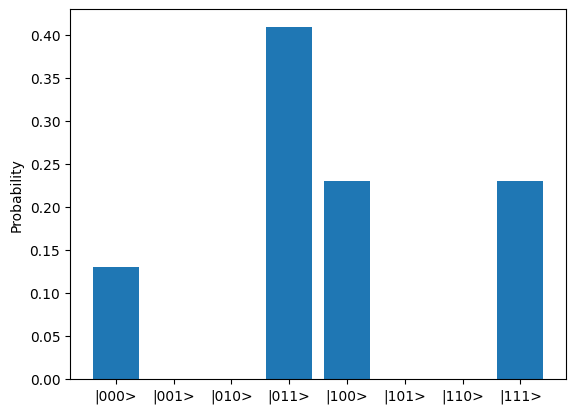

In [31]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

a = 0.36
b = 0.64

A = np.array(
    [[a,  0, 0,  b],
     [0, -a, b,  0],
     [0,  b, a,  0],
     [b,  0, 0, -a]]
)

LCU = qml.pauli_decompose(A)
LCU_coeffs, LCU_ops = LCU.terms()

alphas = (np.sqrt(LCU_coeffs) / np.linalg.norm(np.sqrt(LCU_coeffs)))

dev = qml.device("default.qubit", wires=3)

ops = LCU_ops
unitaries = [qml.map_wires(op, {0: 1, 1: 2}) for op in ops]

@qml.qnode(dev)
def lcu_circuit():
    qml.StatePrep(alphas, wires=0)
    qml.Select(unitaries, control=0)
    qml.adjoint(qml.StatePrep(alphas, wires=0))
    return(qml.state())

state = lcu_circuit()
print(state)

# Reshape into (ancilla, target_system)
# qubit 0 is ancilla, qubits 1-2 are target
state_matrix = state.reshape(2, 4)  # 2 ancilla states, 4 target states

# Post-select: keep only ancilla = |0> part
post_selected = state_matrix[0]

print("Post-selected state:", post_selected)
print("Norm:", np.linalg.norm(post_selected))

# Normalize
result = post_selected / np.linalg.norm(post_selected)
print("Normalized result:", np.round(result, 4))
#print(np.real(np.round(output_matrix,2)))

probs = np.abs(state)**2
labels = [f'|{i:03b}>' for i in range(8)]
plt.bar(labels, probs)
plt.ylabel('Probability')
plt.show()

In [50]:
n_layers = 2
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

a = 0.36
b = 0.64

B = np.array(
    [[a,  0, 0,  b],
     [0, -a, b,  0],
     [0,  b, a,  0],
     [b,  0, 0, -a]]
)

weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.uniform(0, np.pi, weights_shape)

x = np.random.uniform(0, np.pi, n_qubits)

@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

print(full_pipeline(x, weights))

0.40454513023626776
